# Quantitative Risk Analysis: Amazon Risk Register Monte Carlo Simulation

This notebook converts the existing Amazon qualitative risk register into a quantitative Monte Carlo risk simulation.

**Main idea:**  
The original risk register uses likelihood, impact, and risk score. This notebook adds a financial-loss simulation for the highest core risk: **R1 Cybersecurity & Data Privacy**.

The simulation uses three-point estimates:

- **Optimistic loss:** minor event / limited disruption
- **Most likely loss:** moderate event / meaningful disruption
- **Pessimistic loss:** severe event / major breach, downtime, regulatory or reputational impact

The result is a range of possible financial losses instead of one single risk score.


## 1. Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make results reproducible
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 2. Load the existing Amazon risk register

Keep the Excel file in the same folder as this notebook. If the file name is slightly different, update `excel_file` below.


In [4]:
# File path: update this only if your Excel file name changes
excel_file = "ALY6130_Risk Register_Group3_Amazon.xlsx"

# If running in another folder, try to locate the file in the current directory first
if not os.path.exists(excel_file):
    possible_files = [f for f in os.listdir('.') if f.endswith('.xlsx') and 'Risk' in f]
    print("Excel file not found with the default name.")
    print("Possible Excel files in this folder:", possible_files)
else:
    print("Excel file found:", excel_file)


Excel file found: ALY6130_Risk Register_Group3_Amazon.xlsx


In [6]:
# Load the Amazon Risk Register workbook
# Keep the Excel file in the same folder as this notebook when running locally.

file_path = "ALY6130_Risk Register_Group3_Amazon.xlsx"

# Backup filename if the workbook was downloaded with a duplicate suffix
if not os.path.exists(file_path):
    file_path = "ALY6130_Risk Register_Group3_Amazon(1).xlsx"

# Read the Risk Register sheet from the workbook
# Only the required columns are selected because the original workbook contains multiple template sections.
df_risk_register = pd.read_excel(
    file_path,
    sheet_name="RiskRegister",
    usecols=["Risk #", "The Risk of/That", "Likelihood Score", "Impact Score"]
)

# Preview the first few rows
df_risk_register.head()

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Failure of AI warehouse strategy to achieve ex...,5,8
1,2,Public backlash over workforce replacement,3,6
2,3,Competitors implementing superior warehouse te...,9,8
3,4,Dependence on third party technology vendors,7,4
4,5,Warehouse operations interruption,7,9


## 3. Clean and display the core risk table

In [7]:
# The Amazon Core Risk sheet has its real header in row 1, based on the uploaded file structure
core_risk = pd.read_excel(excel_file, sheet_name="Amazon Core Risk", header=1)

# Remove fully empty rows and columns
core_risk = core_risk.dropna(how='all').dropna(axis=1, how='all')

# Standardize columns just in case there are spacing issues
core_risk.columns = [str(c).strip() for c in core_risk.columns]

core_risk


,Core Risk,Category,Likelihood,Impact,Score,Related Risk #
0,R1 Cybersecurity & Data Privacy,Negative,8.0,9.0,72.0,"22, 23, 24, 25, 26, 27, 32, 34"
1,R2 Technology Reliability & AI Integration,Negative,7.0,8.0,56.0,"5, 6, 7, 8, 9, 15, 16, 17, 18, 19, 20, 21"
2,R3 AI Market Expansion Opportunity,Positive,6.0,7.0,42.0,"1, 2, 3, 4, 10, 11, 28, 29, 30, 31"
3,Supporting Organizational Risks,NaN,NaN,NaN,NaN,"12, 13, 14, 33, 35, 36, 37"


## 4. Select the highest-priority risk for quantitative analysis

For this assignment, we select **R1 Cybersecurity & Data Privacy** because it has the highest score among the core risks.


In [8]:
# Convert numeric columns
for col in ["Likelihood", "Impact", "Score"]:
    if col in core_risk.columns:
        core_risk[col] = pd.to_numeric(core_risk[col], errors='coerce')

# Select highest scoring core risk
selected_risk = core_risk.sort_values("Score", ascending=False).iloc[0]
selected_risk


Core Risk         R1 Cybersecurity & Data Privacy
Category                                 Negative
Likelihood                                    8.0
Impact                                        9.0
Score                                        72.0
Related Risk #     22, 23, 24, 25, 26, 27, 32, 34
Name: 0, dtype: object

In [9]:
risk_name = selected_risk["Core Risk"]
risk_category = selected_risk["Category"]
likelihood = selected_risk["Likelihood"]
impact = selected_risk["Impact"]
score = selected_risk["Score"]
related_risks = str(selected_risk["Related Risk #"])

print("Selected Risk:", risk_name)
print("Category:", risk_category)
print("Likelihood:", likelihood)
print("Impact:", impact)
print("Qualitative Score:", score)
print("Related Risk Numbers:", related_risks)


Selected Risk: R1 Cybersecurity & Data Privacy
Category: Negative
Likelihood: 8.0
Impact: 9.0
Qualitative Score: 72.0
Related Risk Numbers: 22, 23, 24, 25, 26, 27, 32, 34


## 5. Connect the selected core risk to detailed risks

The core risk R1 is linked to specific items in the full risk register. This makes the quantitative analysis grounded in the existing qualitative risk work.


In [10]:
# Extract related risk numbers from a comma-separated string like '22, 23, 24'
related_numbers = []
for item in related_risks.replace(';', ',').split(','):
    item = item.strip()
    if item.isdigit():
        related_numbers.append(int(item))

# Filter detailed risk register
related_risk_register = risk_register[risk_register["Risk #"].isin(related_numbers)][[
    "Risk #", "The Risk of/That", "Likelihood Score", "Impact Score"
]].copy()

related_risk_register["Risk Score"] = related_risk_register["Likelihood Score"] * related_risk_register["Impact Score"]
related_risk_register.sort_values("Risk Score", ascending=False)


,Risk #,The Risk of/That,Likelihood Score,Impact Score,Risk Score
21,22,Customer data breach,9,9,81
31,32,Data privacy violations,9,8,72
23,24,Ransomware attacks,7,9,63
22,23,Unauthorized system access,7,8,56
33,34,AI ethics concerns,7,8,56
24,25,API security vulnerabilities,3,6,18
25,26,Insider threats,3,6,18
26,27,IoT device hacking,3,6,18


## 6. Define Monte Carlo simulation assumptions

Because the risk register provides qualitative scores instead of exact dollar losses, we convert the risk into a financial-loss range using three-point estimates.

The values below are in **millions of dollars ($M)**. They are assumptions for class simulation purposes and can be adjusted if the professor requires a different scale.

- **Optimistic:** $5M to $20M
- **Most likely:** $20M to $80M
- **Pessimistic:** $80M to $300M

The simulation uses a weighted PERT-style estimate:


`Estimated Loss = (Optimistic + 4 × Most Likely + Pessimistic) / 6`


In [11]:
# Number of Monte Carlo iterations
iterations = 10000

# Estimated financial loss ranges in $ millions
optimistic_min, optimistic_max = 5, 20
most_likely_min, most_likely_max = 20, 80
pessimistic_min, pessimistic_max = 80, 300

# Generate random simulated values
optimistic_loss = np.random.uniform(optimistic_min, optimistic_max, iterations)
most_likely_loss = np.random.uniform(most_likely_min, most_likely_max, iterations)
pessimistic_loss = np.random.uniform(pessimistic_min, pessimistic_max, iterations)

# PERT-style weighted estimate
estimated_loss = (optimistic_loss + 4 * most_likely_loss + pessimistic_loss) / 6

simulation_df = pd.DataFrame({
    "Optimistic Loss ($M)": optimistic_loss,
    "Most Likely Loss ($M)": most_likely_loss,
    "Pessimistic Loss ($M)": pessimistic_loss,
    "Estimated Loss ($M)": estimated_loss
})

simulation_df.head()


,Optimistic Loss ($M),Most Likely Loss ($M),Pessimistic Loss ($M),Estimated Loss ($M)
0,10.618102,42.418449,240.599628,70.148588
1,19.260715,39.974726,120.592639,49.958709
2,15.979909,30.569235,156.260733,49.086263
3,13.979877,56.436000,225.921740,77.607603
4,7.340280,48.597450,186.059656,64.631622


## 7. Summary statistics

In [12]:
summary_stats = simulation_df["Estimated Loss ($M)"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95])
summary_stats


count    10000.000000
mean        67.251775
std         15.455377
min         29.291699
5%          41.002621
25%         56.216044
50%         67.482991
75%         78.369827
90%         87.967437
95%         92.965209
max        104.928543
Name: Estimated Loss ($M), dtype: float64

In [13]:
mean_loss = simulation_df["Estimated Loss ($M)"].mean()
median_loss = simulation_df["Estimated Loss ($M)"].median()
p90_loss = simulation_df["Estimated Loss ($M)"].quantile(0.90)
p95_loss = simulation_df["Estimated Loss ($M)"].quantile(0.95)
max_loss = simulation_df["Estimated Loss ($M)"].max()

result_table = pd.DataFrame({
    "Metric": ["Mean Loss", "Median Loss", "90th Percentile Loss", "95th Percentile Loss", "Maximum Simulated Loss"],
    "Estimated Loss ($M)": [mean_loss, median_loss, p90_loss, p95_loss, max_loss]
})

result_table["Estimated Loss ($M)"] = result_table["Estimated Loss ($M)"].round(2)
result_table


,Metric,Estimated Loss ($M)
0,Mean Loss,67.25
1,Median Loss,67.48
2,90th Percentile Loss,87.97
3,95th Percentile Loss,92.97
4,Maximum Simulated Loss,104.93


## 8. Visualize the simulated loss distribution

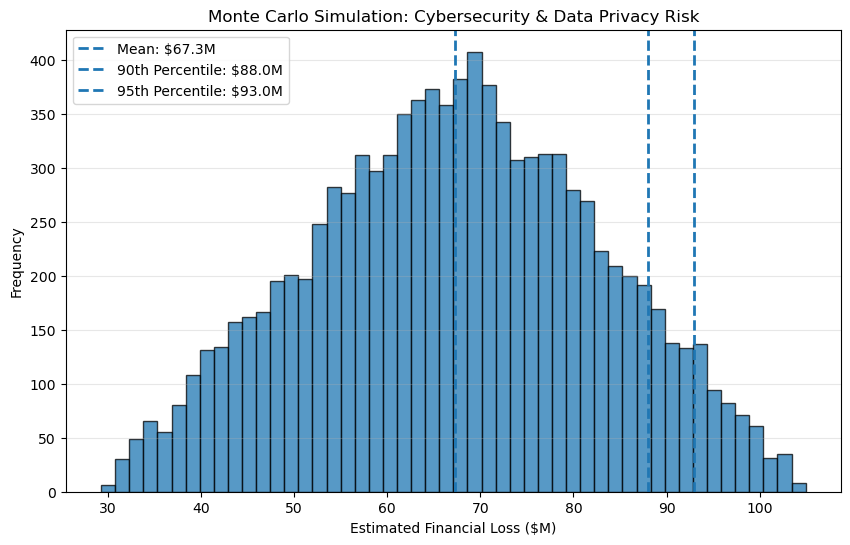

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(simulation_df["Estimated Loss ($M)"], bins=50, edgecolor='black', alpha=0.75)
plt.axvline(mean_loss, linestyle='--', linewidth=2, label=f"Mean: ${mean_loss:.1f}M")
plt.axvline(p90_loss, linestyle='--', linewidth=2, label=f"90th Percentile: ${p90_loss:.1f}M")
plt.axvline(p95_loss, linestyle='--', linewidth=2, label=f"95th Percentile: ${p95_loss:.1f}M")
plt.title("Monte Carlo Simulation: Cybersecurity & Data Privacy Risk")
plt.xlabel("Estimated Financial Loss ($M)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## 9. Probability of exceeding loss thresholds

In [15]:
thresholds = [50, 75, 100, 125, 150]
threshold_results = []

for threshold in thresholds:
    probability = (simulation_df["Estimated Loss ($M)"] > threshold).mean()
    threshold_results.append({
        "Loss Threshold ($M)": threshold,
        "Probability of Exceeding Threshold": probability
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df["Probability of Exceeding Threshold"] = (threshold_df["Probability of Exceeding Threshold"] * 100).round(2).astype(str) + "%"
threshold_df


,Loss Threshold ($M),Probability of Exceeding Threshold
0,50,85.28%
1,75,31.92%
2,100,0.93%
3,125,0.0%
4,150,0.0%


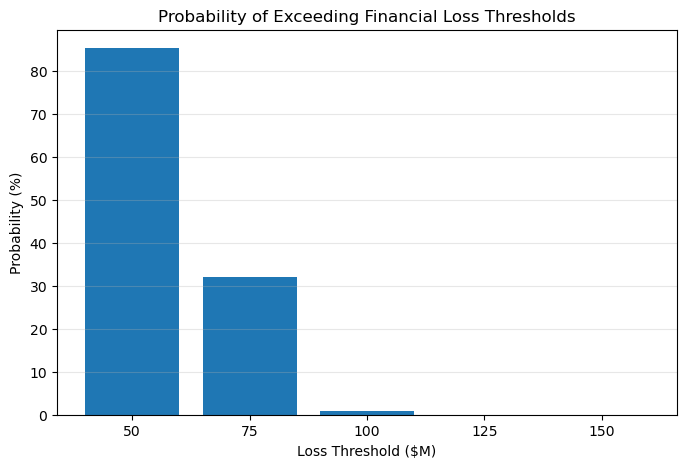

In [16]:
# Bar chart for threshold probabilities
threshold_plot_df = threshold_df.copy()
threshold_plot_df["Probability (%)"] = threshold_plot_df["Probability of Exceeding Threshold"].str.replace('%', '', regex=False).astype(float)

plt.figure(figsize=(8, 5))
plt.bar(threshold_plot_df["Loss Threshold ($M)"].astype(str), threshold_plot_df["Probability (%)"])
plt.title("Probability of Exceeding Financial Loss Thresholds")
plt.xlabel("Loss Threshold ($M)")
plt.ylabel("Probability (%)")
plt.grid(axis='y', alpha=0.3)
plt.show()


## 10. Risk interpretation for report or presentation

Run the cell below to generate a paragraph that can be copied into the assignment report.


In [17]:
interpretation = f'''
The quantitative risk analysis selected {risk_name} because it has the highest qualitative risk score in the Amazon core risk register, with a likelihood score of {likelihood}, an impact score of {impact}, and a total score of {score}. The Monte Carlo simulation translates this qualitative risk into a probabilistic financial-loss estimate. Based on 10,000 simulated scenarios, the expected loss is approximately ${mean_loss:.2f} million, while the 90th percentile loss is approximately ${p90_loss:.2f} million and the 95th percentile loss is approximately ${p95_loss:.2f} million. This means Amazon should consider the 90th and 95th percentile values as risk-adjusted planning thresholds for cybersecurity contingency planning, security investment, incident response capacity, and data privacy controls. Compared with the original qualitative score, this quantitative approach provides a clearer estimate of potential financial exposure and supports more evidence-based decision-making.
'''

print(interpretation)



The quantitative risk analysis selected R1 Cybersecurity & Data Privacy because it has the highest qualitative risk score in the Amazon core risk register, with a likelihood score of 8.0, an impact score of 9.0, and a total score of 72.0. The Monte Carlo simulation translates this qualitative risk into a probabilistic financial-loss estimate. Based on 10,000 simulated scenarios, the expected loss is approximately $67.25 million, while the 90th percentile loss is approximately $87.97 million and the 95th percentile loss is approximately $92.97 million. This means Amazon should consider the 90th and 95th percentile values as risk-adjusted planning thresholds for cybersecurity contingency planning, security investment, incident response capacity, and data privacy controls. Compared with the original qualitative score, this quantitative approach provides a clearer estimate of potential financial exposure and supports more evidence-based decision-making.



## 11. Optional: compare all three core risks with simple simulated exposure

This section is optional. It creates a simplified comparison across core risks by scaling financial exposure according to the original risk score. This can be used if you want one additional chart showing why R1 is prioritized.


In [18]:
core_compare = core_risk.dropna(subset=["Score"]).copy()
core_compare = core_compare[core_compare["Core Risk"] != "Supporting Organizational Risks"]

# Scale simulated exposure based on risk score relative to highest score
max_score = core_compare["Score"].max()
core_compare["Relative Exposure Index"] = core_compare["Score"] / max_score
core_compare["Estimated Mean Exposure ($M)"] = core_compare["Relative Exposure Index"] * mean_loss
core_compare[["Core Risk", "Category", "Likelihood", "Impact", "Score", "Estimated Mean Exposure ($M)"]]


,Core Risk,Category,Likelihood,Impact,Score,Estimated Mean Exposure ($M)
0,R1 Cybersecurity & Data Privacy,Negative,8.0,9.0,72.0,67.251775
1,R2 Technology Reliability & AI Integration,Negative,7.0,8.0,56.0,52.306936
2,R3 AI Market Expansion Opportunity,Positive,6.0,7.0,42.0,39.230202


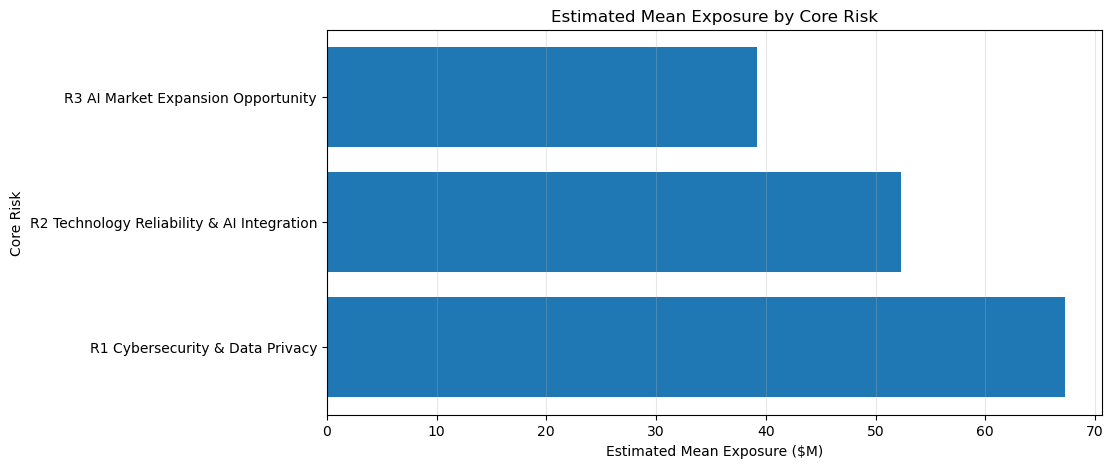

In [19]:
plt.figure(figsize=(10, 5))
plt.barh(core_compare["Core Risk"], core_compare["Estimated Mean Exposure ($M)"])
plt.title("Estimated Mean Exposure by Core Risk")
plt.xlabel("Estimated Mean Exposure ($M)")
plt.ylabel("Core Risk")
plt.grid(axis='x', alpha=0.3)
plt.show()


## 12. Final conclusion

The Monte Carlo simulation improves the existing Amazon risk register by moving from a single qualitative risk score to a probability-based financial exposure estimate. This helps decision-makers understand not only which risk is most important, but also how large the potential loss could be under different scenarios.
